In [ ]:
import os
l = 5
n_spheroid = 30
for i in range(1,4):
    test_dir = "runs/kv_10_l_{}_n_hidden_{:03d}_increase/{:03d}/".format(l,n_spheroid,i)
    os.system("python single_pattern.py {}".format(test_dir))
    test_dir = "runs/kv_10_l_{}_n_hidden_{:03d}_decrease/{:03d}/".format(l,n_spheroid,i)
    os.system("python single_pattern.py {}".format(test_dir))

Starting a new run in dir: runs/kv_10_l_5_n_hidden_040/001/
Training random cells in directory: runs/kv_10_l_5_n_hidden_040/001/
     Parameters for training:
     cpp_executable_dir: /home/shabeeb/Projects/tvm-fire/build/
     tolerance: 1e-06
     learning_rate: 10.0
     clear_interval: 50
     max_iters: 10000
Initialization start ...


Initial F_rms: 9.98567e-08
   Minimization terminated:
   Input is already minimized at FIRE_equilibrium_tolerance: 1e-07




Starting iteration: 1






-------------------------------------
Step 1: Evaluate and store the current (free state) areas of hidden (non-target) cells
-------------------------------------




-------------------------------------
Step 2: CLAMPING
-------------------------------------


Clamping iteration 0
Cell: 85, Final Target Stress: 0.235701476670543 Temporary Target Stress: 0.2308185902522888, Current stress: 0.28453034085308526, s0: 5.0
Binary search complete, found s0 = 5.072574748050876
Initialization start ...


I

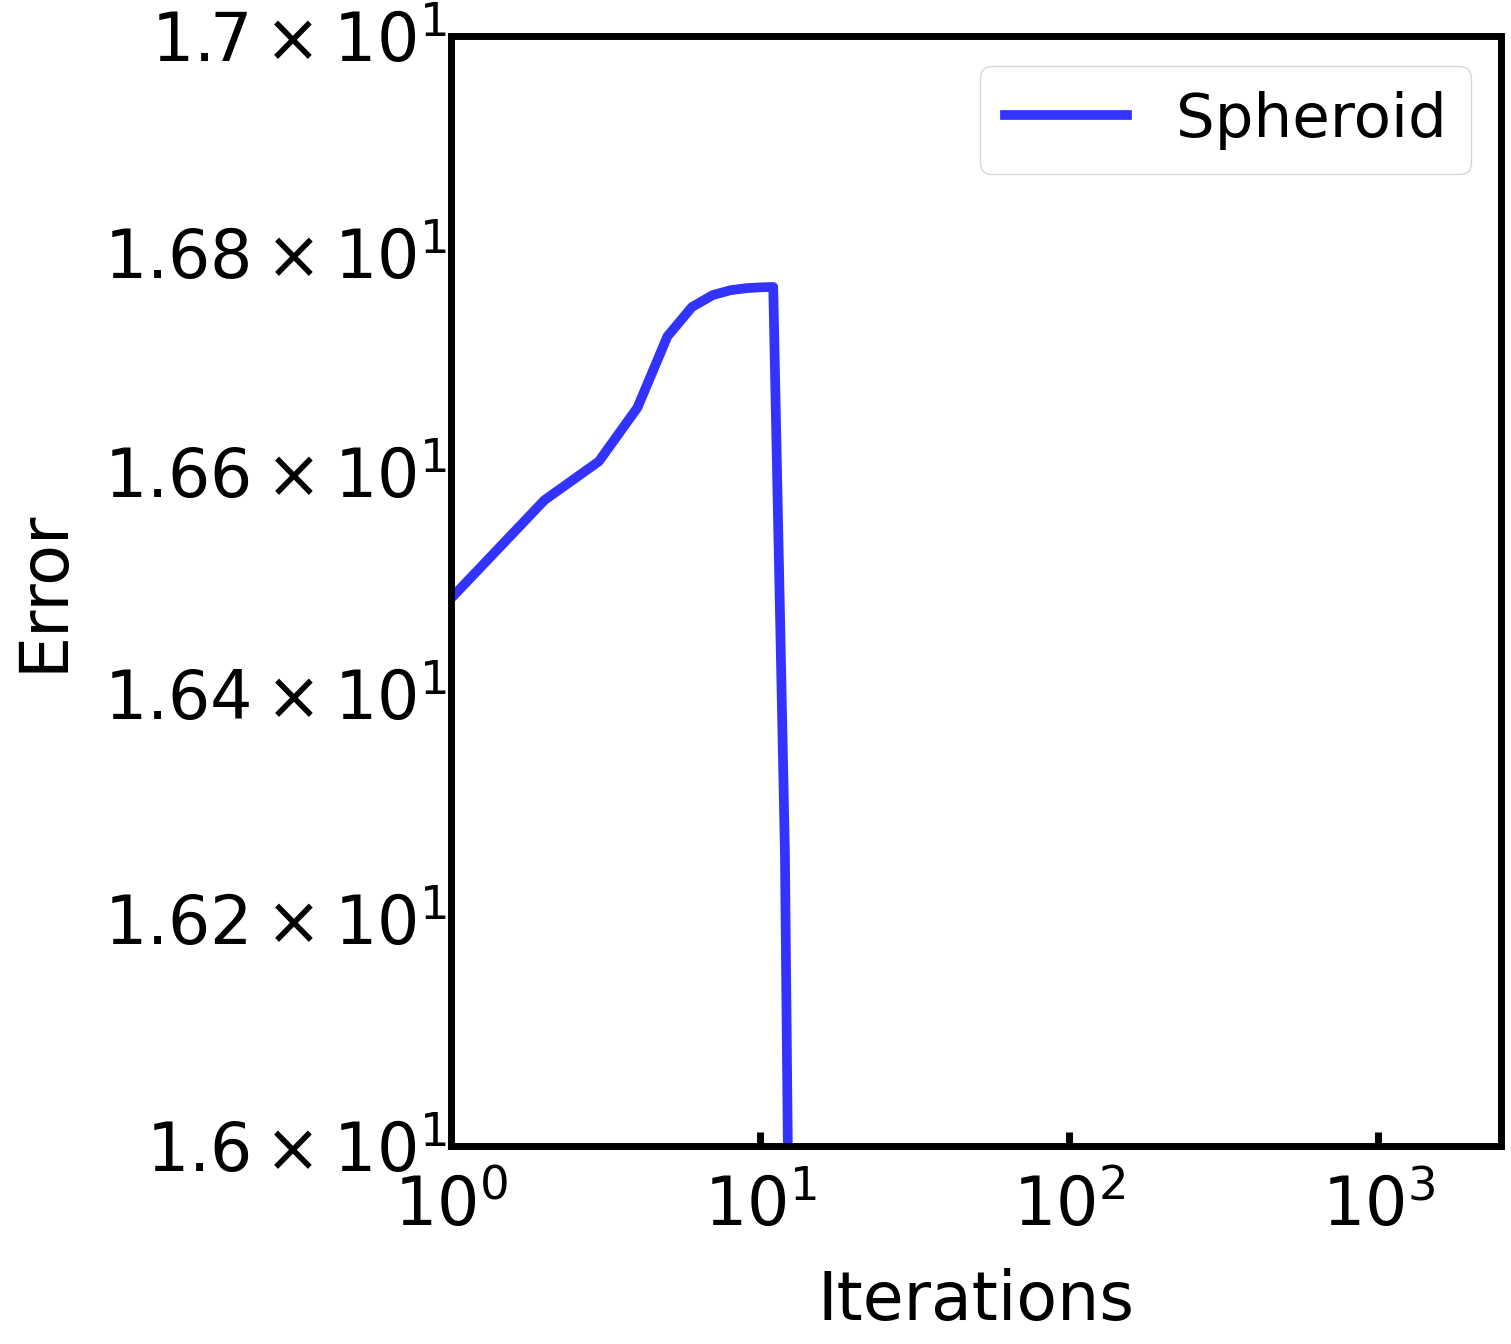

In [ ]:
from toolbox.periodic import PeriodicTissue
import matplotlib.pyplot as plt
dir = "tests/1_cell_new_code_spheroid/"
areas = []
iters =[100*i for i in range(25)]
with open("{}frozen_cells.txt".format(dir), 'r') as f:
    frozen_cells = [int(line.strip()) for line in f.readlines()]
with open("{}spheroid_cells.txt".format(dir), 'r') as f:
    spheroid_cells = [int(line.strip()) for line in f.readlines()]
for iter in iters:
    sample = PeriodicTissue.from_config(dir+"files/", "{:07d}.bulk.txt".format(iter))
    sample.write_periodic_vtk("net_system_{}.vtk".format(iter))
    frozen_polygons = []
    spheroid_polygons = []
    for cellID in frozen_cells:
        cell = sample.cells_[cellID]
        frozen_polygons+=cell.polygons_
    for cellID in spheroid_cells:
        cell = sample.cells_[cellID]
        spheroid_polygons+=cell.polygons_
    
    surface_polygons = list(set(frozen_polygons).intersection(set(spheroid_polygons)))
    surface_area = 0
    for polygonID in surface_polygons:
        polygon = sample.polygons_[polygonID]
        surface_area += polygon.area_
    areas.append(surface_area)


from toolbox.manuscriptPlots import plot 
import numpy as np
plotter = plot()
costs_sp = np.loadtxt("tests/1_cell_new_code_spheroid/q_values.txt")

plotter.set_ylim(16,17)
plotter.set_xlim(1,2500)
plotter.set_xticks([50*i*i for i in range(6)])
plotter.set_xlabel("Iterations")
# plotter.set_ylabel(r"$<\sigma_{shear}/(K_V V_0)>$")
plotter.set_ylabel("Error")
# plotter.set_yScaled()
# plotter.set_xScaled()
plotter.initialize_figure()
plotter.set_xLog()
plotter.set_yLog()
plotter.plot_xy([i for i in range(len(areas))], areas, color='blue', label ="Spheroid")
plotter.ax.legend()


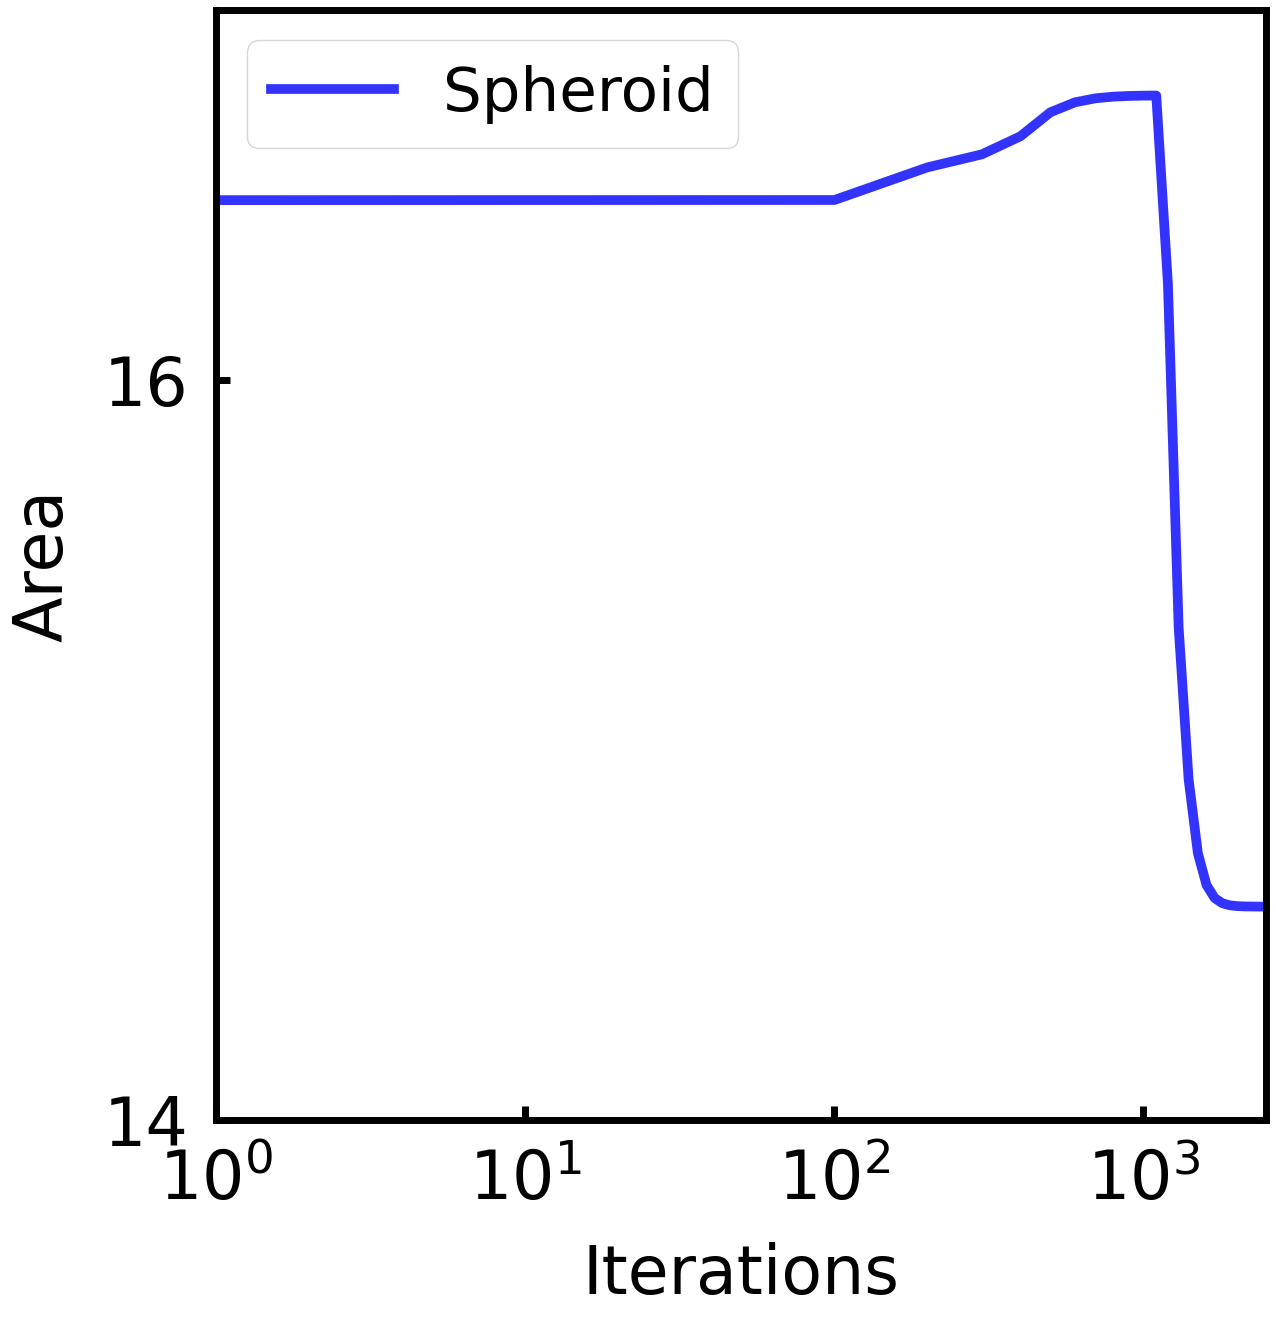

In [23]:
plotter = plot()
costs_sp = np.loadtxt("tests/1_cell_new_code_spheroid/q_values.txt")

plotter.set_ylim(14,17)
plotter.set_xlim(1,2500)
plotter.set_xticks([50*i for i in range(6)])
plotter.set_yticks([2*i for i in range(50)])

plotter.set_xlabel("Iterations")
# plotter.set_ylabel(r"$<\sigma_{shear}/(K_V V_0)>$")
plotter.set_ylabel("Area")
# plotter.set_yScaled()
# plotter.set_xScaled()
plotter.initialize_figure()
plotter.set_xLog()
# plotter.set_yLog()
plotter.plot_xy([100*i for i in range(len(areas))], areas, color='blue', label ="Spheroid")
plotter.ax.legend()

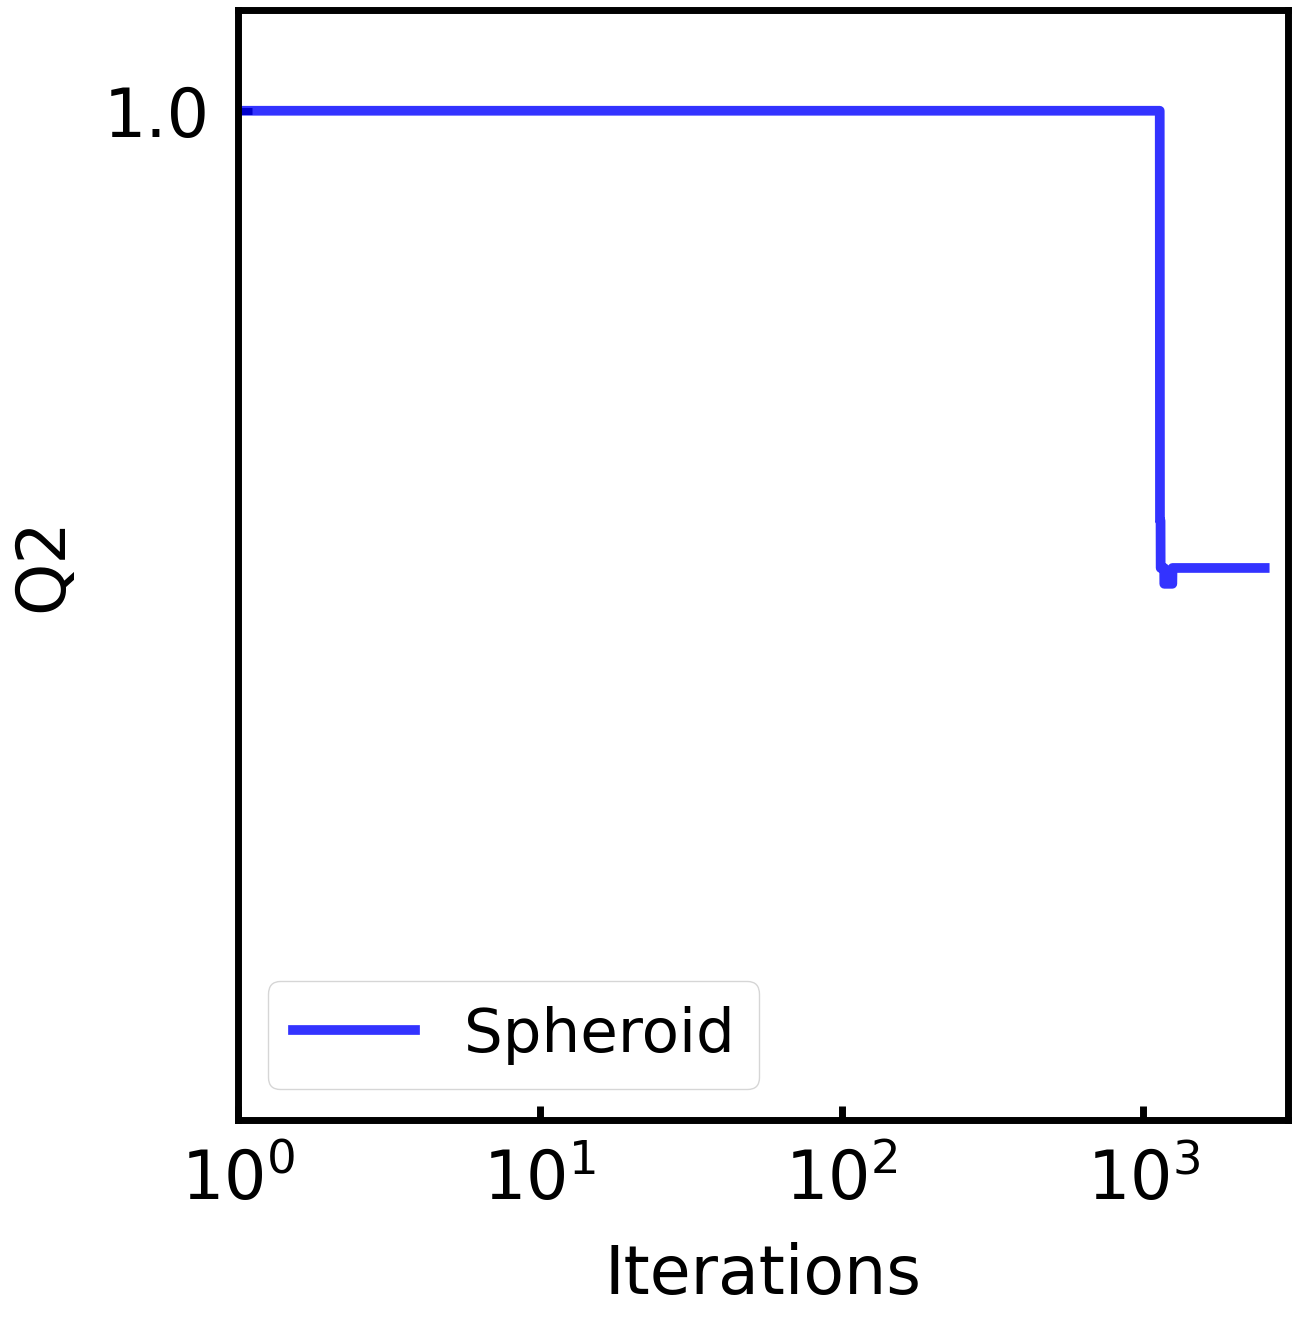

In [19]:
from toolbox.manuscriptPlots import plot 
import numpy as np
plotter = plot()
costs_sp = np.loadtxt("tests/1_cell_new_code_spheroid/q_values.txt")
# costs_pe = np.loadtxt("tests/1_cell_new_code_full_system/costs.txt")

plotter.set_ylim(0,1.1)
plotter.set_xlim(1,3000)
# plotter.set_ylim(1e-7,1e0)
plotter.set_xticks([50*i*i for i in range(50)])
plotter.set_xlabel("Iterations")
# plotter.set_ylabel(r"$<\sigma_{shear}/(K_V V_0)>$")
plotter.set_ylabel("Q2")
# plotter.set_yScaled()
# plotter.set_xScaled()
plotter.initialize_figure()
plotter.set_xLog()
# plotter.set_yLog()
plotter.plot_xy([i for i in range(len(costs_sp))], costs_sp, color='blue', label ="Spheroid")
# plotter.plot_xy([i for i in range(len(costs_pe))], costs_pe, color='red',label ="Full")
plotter.ax.legend()

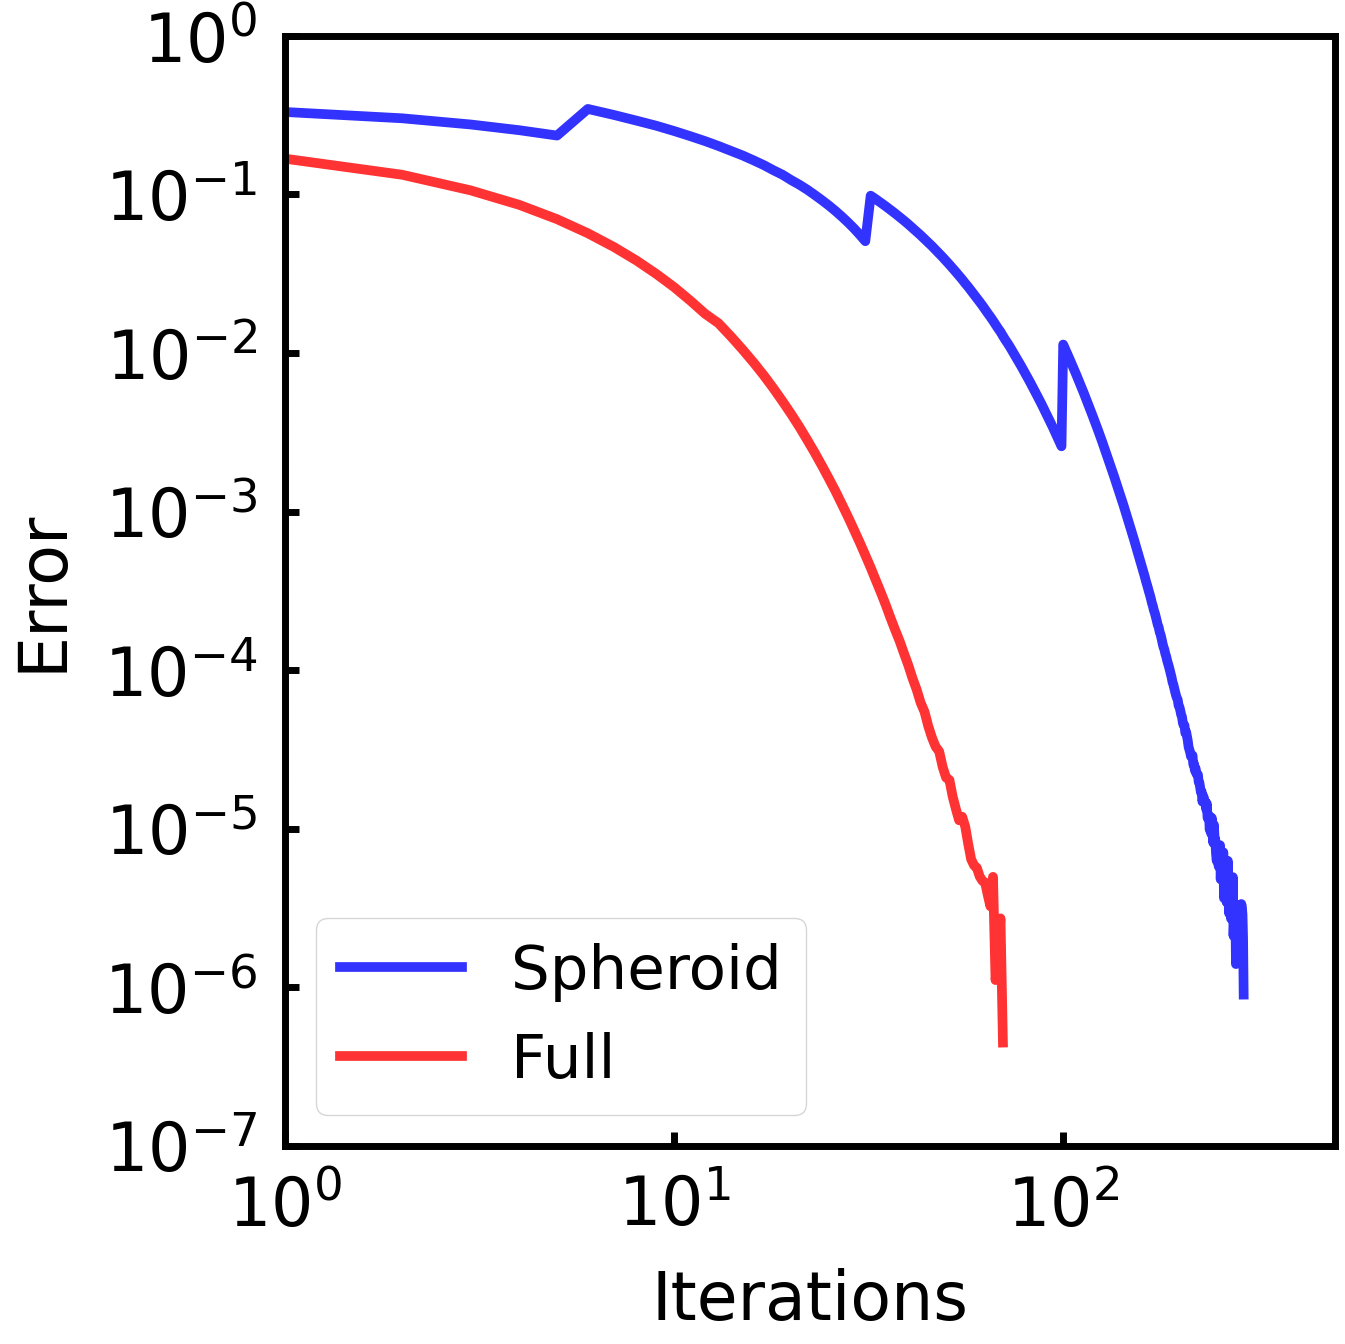

In [37]:
from toolbox.manuscriptPlots import plot 
import numpy as np
plotter = plot()
costs_sp = np.loadtxt("tests/1_cell_new_code_spheroid/costs.txt")
costs_pe = np.loadtxt("tests/1_cell_new_code_full_system/costs.txt")

plotter.set_ylim(0.9,2.5)
plotter.set_xlim(1,500)
plotter.set_ylim(1e-7,1e0)
plotter.set_xticks([50*i*i for i in range(6)])
plotter.set_xlabel("Iterations")
# plotter.set_ylabel(r"$<\sigma_{shear}/(K_V V_0)>$")
plotter.set_ylabel("Error")
# plotter.set_yScaled()
# plotter.set_xScaled()
plotter.initialize_figure()
plotter.set_xLog()
plotter.set_yLog()
plotter.plot_xy([i for i in range(len(costs_sp))], costs_sp, color='blue', label ="Spheroid")
plotter.plot_xy([i for i in range(len(costs_pe))], costs_pe, color='red',label ="Full")
plotter.ax.legend()


In [11]:
import glob
print(glob.glob("tests/two_cell_new_code/*.bulk.txt"))

['tests/two_cell_new_code/0000702.bulk.txt', 'tests/two_cell_new_code/0000705.bulk.txt', 'tests/two_cell_new_code/0000703.bulk.txt', 'tests/two_cell_new_code/0000701.bulk.txt', 'tests/two_cell_new_code/0000704.bulk.txt']


In [ ]:
from toolbox.periodic import PeriodicTissue
from toolbox.cellDriver import CellDriver
import os
import numpy as np

#prepare_dir
test_dir = "tests/test_cell_driver/"
os.system("rm -rf {}".format(test_dir))
os.system("cp -r init/init_homogeneous_6/069/ {}".format(test_dir))

tissue = PeriodicTissue.from_config(test_dir, "minimized.txt")
driver = CellDriver.periodic_tissue(tissue)
driver.set_central_target_cell()
driver.set_direction(np.array([1.0, 0.0, 0.0]))
# driver.evaluate_target_cell_neighbors()
# driver.set_target_cell_neighbors_s0()
driver.set_s0_gradient()
if os.path.isdir("/home/shabeeb/Projects/tvm-fire/build/"):
    driver.set_cpp_executable_dir("/home/shabeeb/Projects/tvm-fire/build/")
if os.path.isdir("/Users/shabeebameen/Projects/tvm-fire/build/"):
    driver.set_cpp_executable_dir("/Users/shabeebameen/Projects/tvm-fire/build/")
driver.set_iter_counter(0)
for _ in range(5):
    driver.single_iteration()
    

In [ ]:
driver._config.write_cell_collection_vtk([driver._target_cell], "result_target_cell.vtk")

In [5]:
from toolbox.periodic import PeriodicTissue
sample = PeriodicTissue.from_config("tests/1_cell_new_code/", "minimized.txt")
sample.calculate_periodic_sample_center()
r_sphere = 2
frozen_cells = [cellID for cellID,cell in sample.cells_.items() if cell.crossBoundary_ or np.linalg.norm(np.subtract(cell.center_,sample.periodic_sample_center_))>r_sphere]
# target_cells = find_random_target_cells(sample, n_cells=n_cells, stress_limits=stress_limits, exclude_cells=exclude_cells)
sample.write_cell_collection_vtk([cellID for cellID in sample.cells_ if not cellID in frozen_cells],"initial_spheroid.vtk",use_scalar=False)


In [26]:
from toolbox.periodic import PeriodicTissue
# sample = PeriodicTissue.from_config("/Users/shabeebameen/Downloads/", "minimized.txt")
import pandas as pd

sample = PeriodicTissue.from_config("/Users/shabeebameen/Downloads/1_cell_new_code_spheroid/files/", "0000001.bulk.txt")
sample.write_cell_collection_vtk([33],"sample_small_target.vtk")

In [6]:
import os
for iter in [100*i for i in range(30)]:
    print(iter)
    if os.path.isfile("/Users/shabeebameen/Downloads/1_cell_new_code_spheroid/files/{:07d}.stresses.csv".format(iter)):
        print(iter, "exists")

0
0 exists
100
100 exists
200
300
300 exists
400
500
500 exists
600
600 exists
700
700 exists
800
900
1000
1000 exists
1100
1200
1300
1400
1500
1600
1600 exists
1700
1800
1900
2000
2000 exists
2100
2200
2300
2400
2500
2600
2700
2800
2900


In [ ]:
import pandas as pd

test = 69
td = {1:0.5,2:5.3}
td_list = list(td.items())
print(td_list)

df = pd.DataFrame(list(td.items()),columns=["a","b"])
df["c"] = test
print(df)
td_loaded = dict(zip(df["a"].to_numpy(),df["b"].to_numpy()))
print(td_loaded)

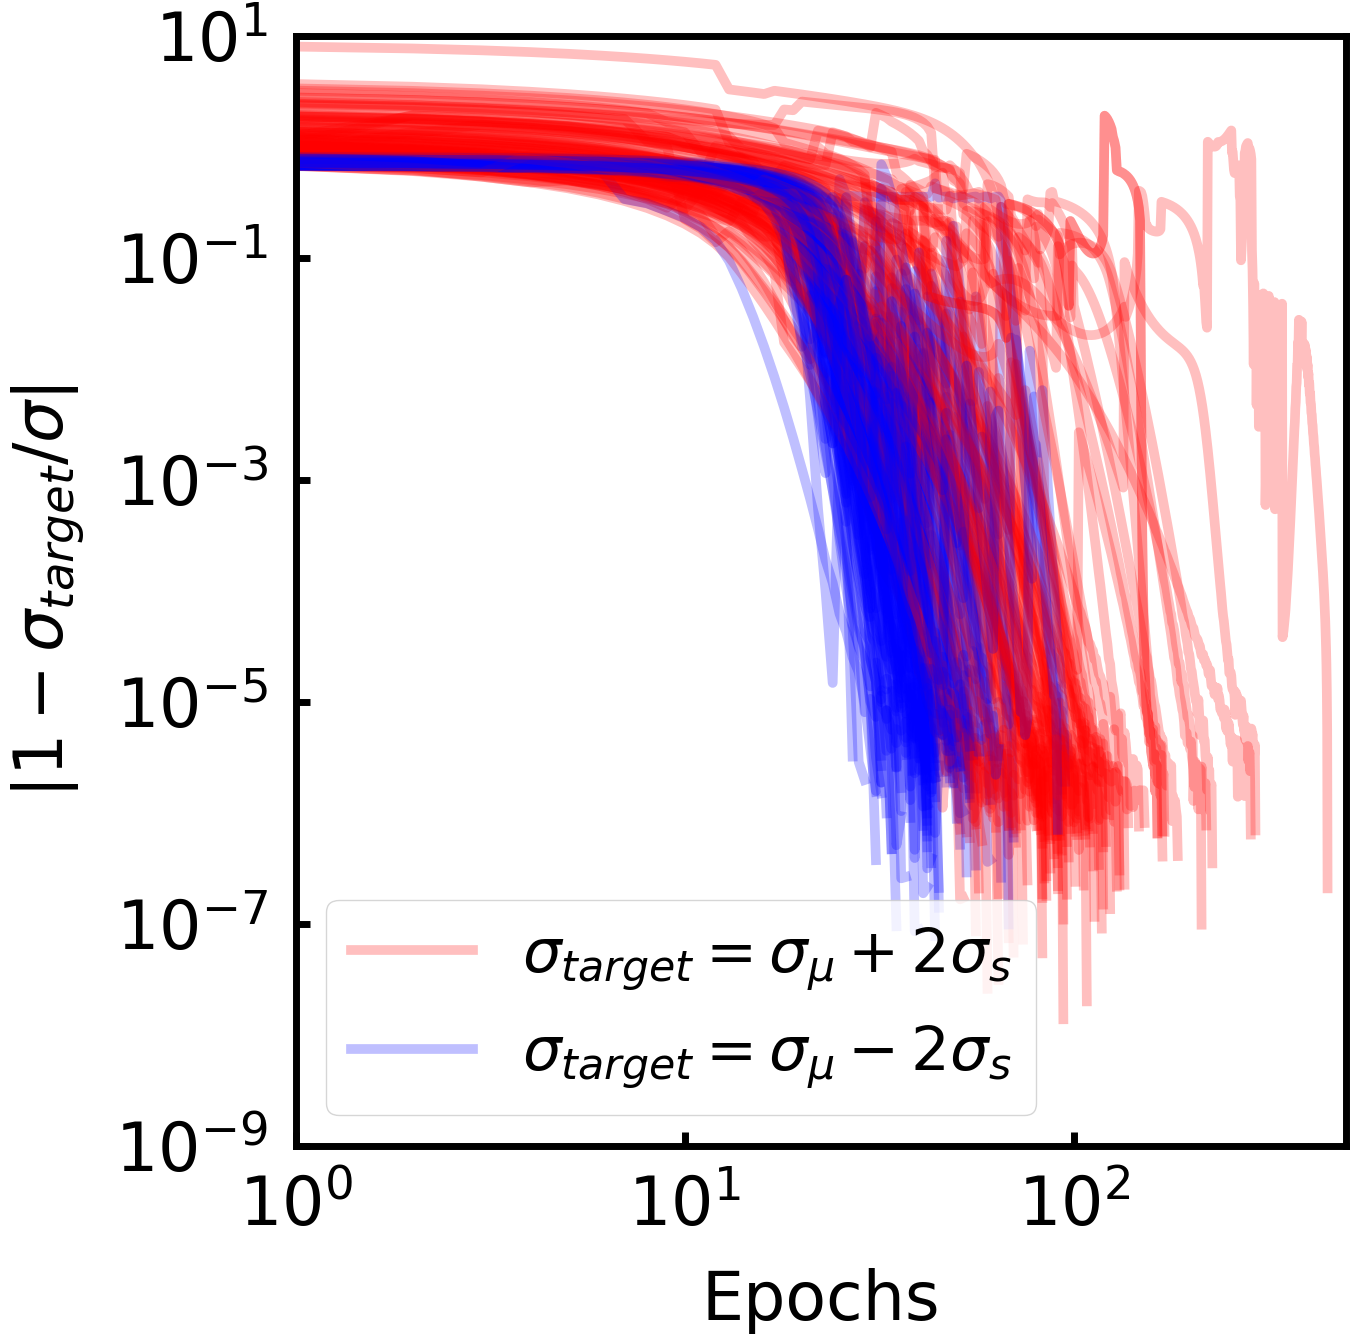

In [12]:
## single cell, errors for all runs
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-9,10)
plotter.set_xlim(1,500)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([5*i for i in range(1,100)])
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$|1-\sigma_{target}/\sigma|$")

plotter.set_yScaled()
plotter.initialize_figure()
for i in range(100):
    
    dir = "data/1_cell_increase_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt(dir+"errors.txt")
    if errors[-1]>5e-6:
        continue
    x_array = [i+1 for i in range(len(errors))]
    plotter.plot_xy(x_array, errors, color ="red", alpha = 0.25,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, errors, color ="red", alpha = 0.25, label = r"$\sigma_{target}=\sigma_\mu + 2\sigma_s$")


    dir = "data/1_cell_decrease_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt(dir+"errors.txt")
    if errors[-1]>5e-6:
        continue
    x_array = [i+1 for i in range(len(errors))]
    plotter.plot_xy(x_array, errors, color ="blue", alpha = 0.25,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, errors, color ="blue", alpha = 0.25, label = r"$\sigma_{target}=\sigma_\mu - 2\sigma_s$")
    

# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
plotter.ax.legend(loc='lower left')
plotter.save_fig("new_graphs/single_cell_errors.jpg")


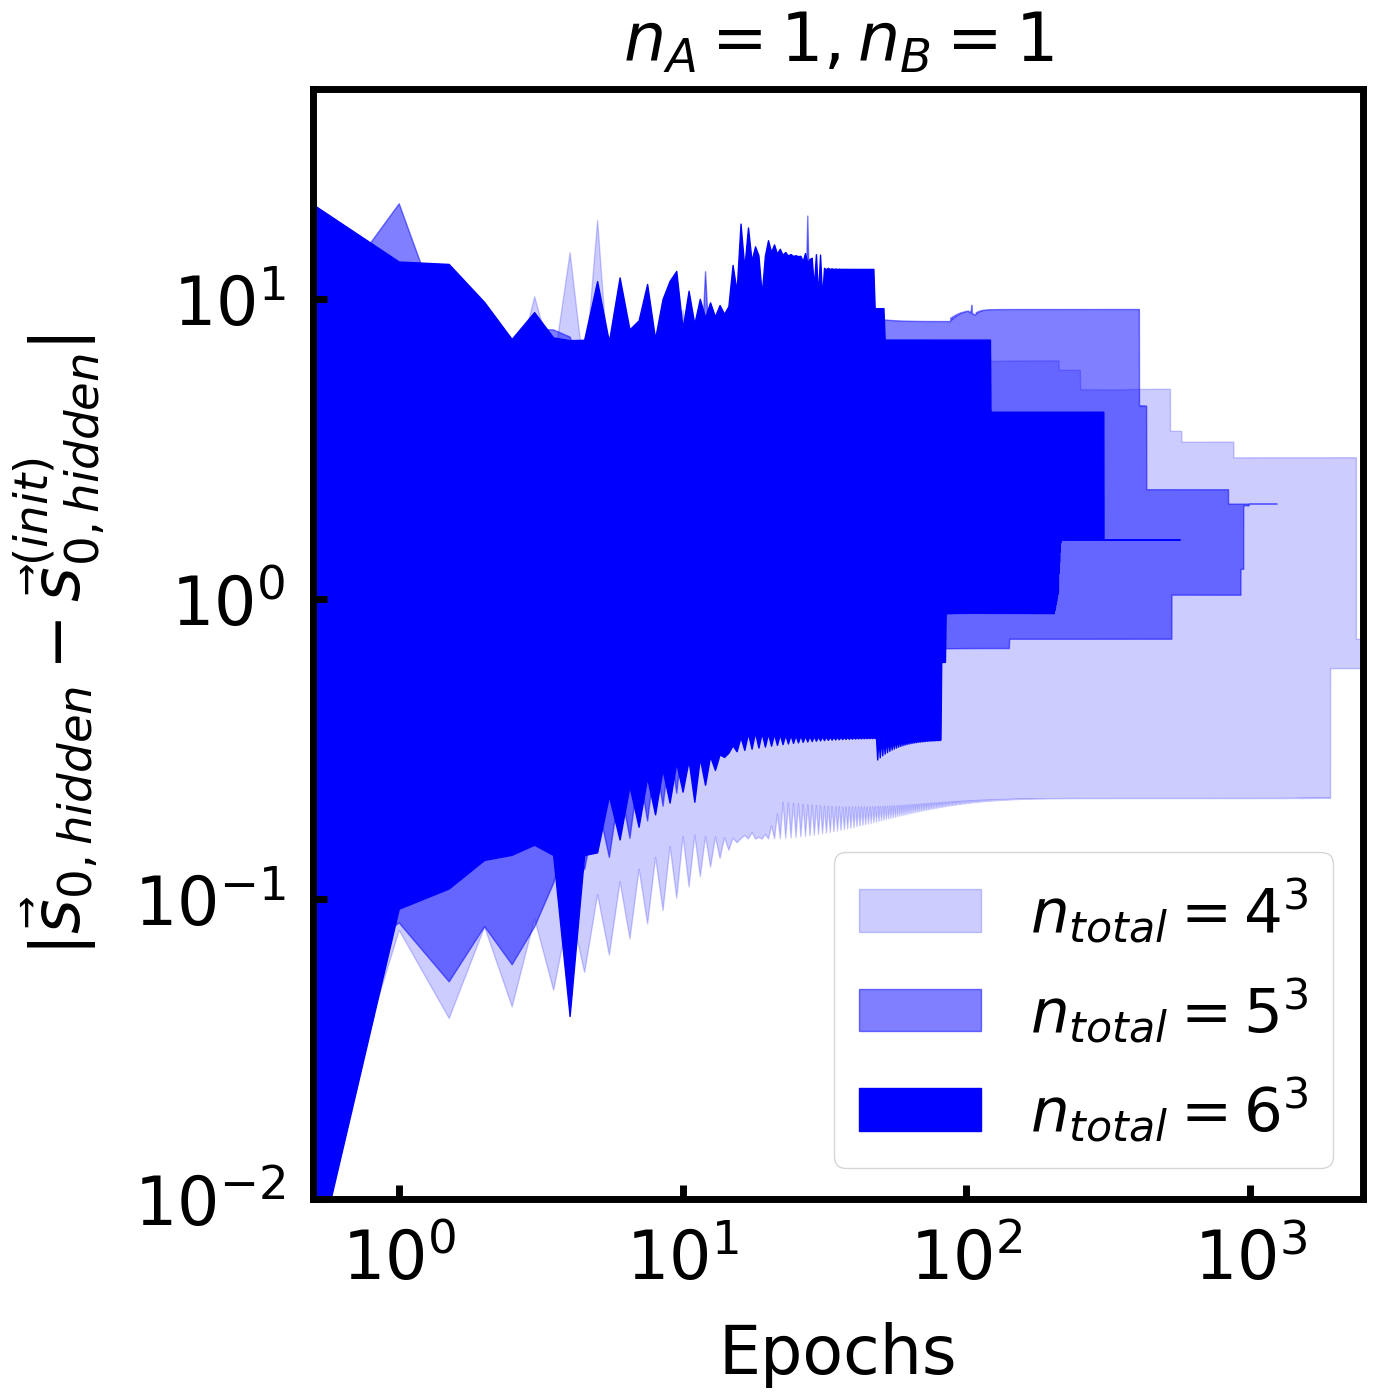

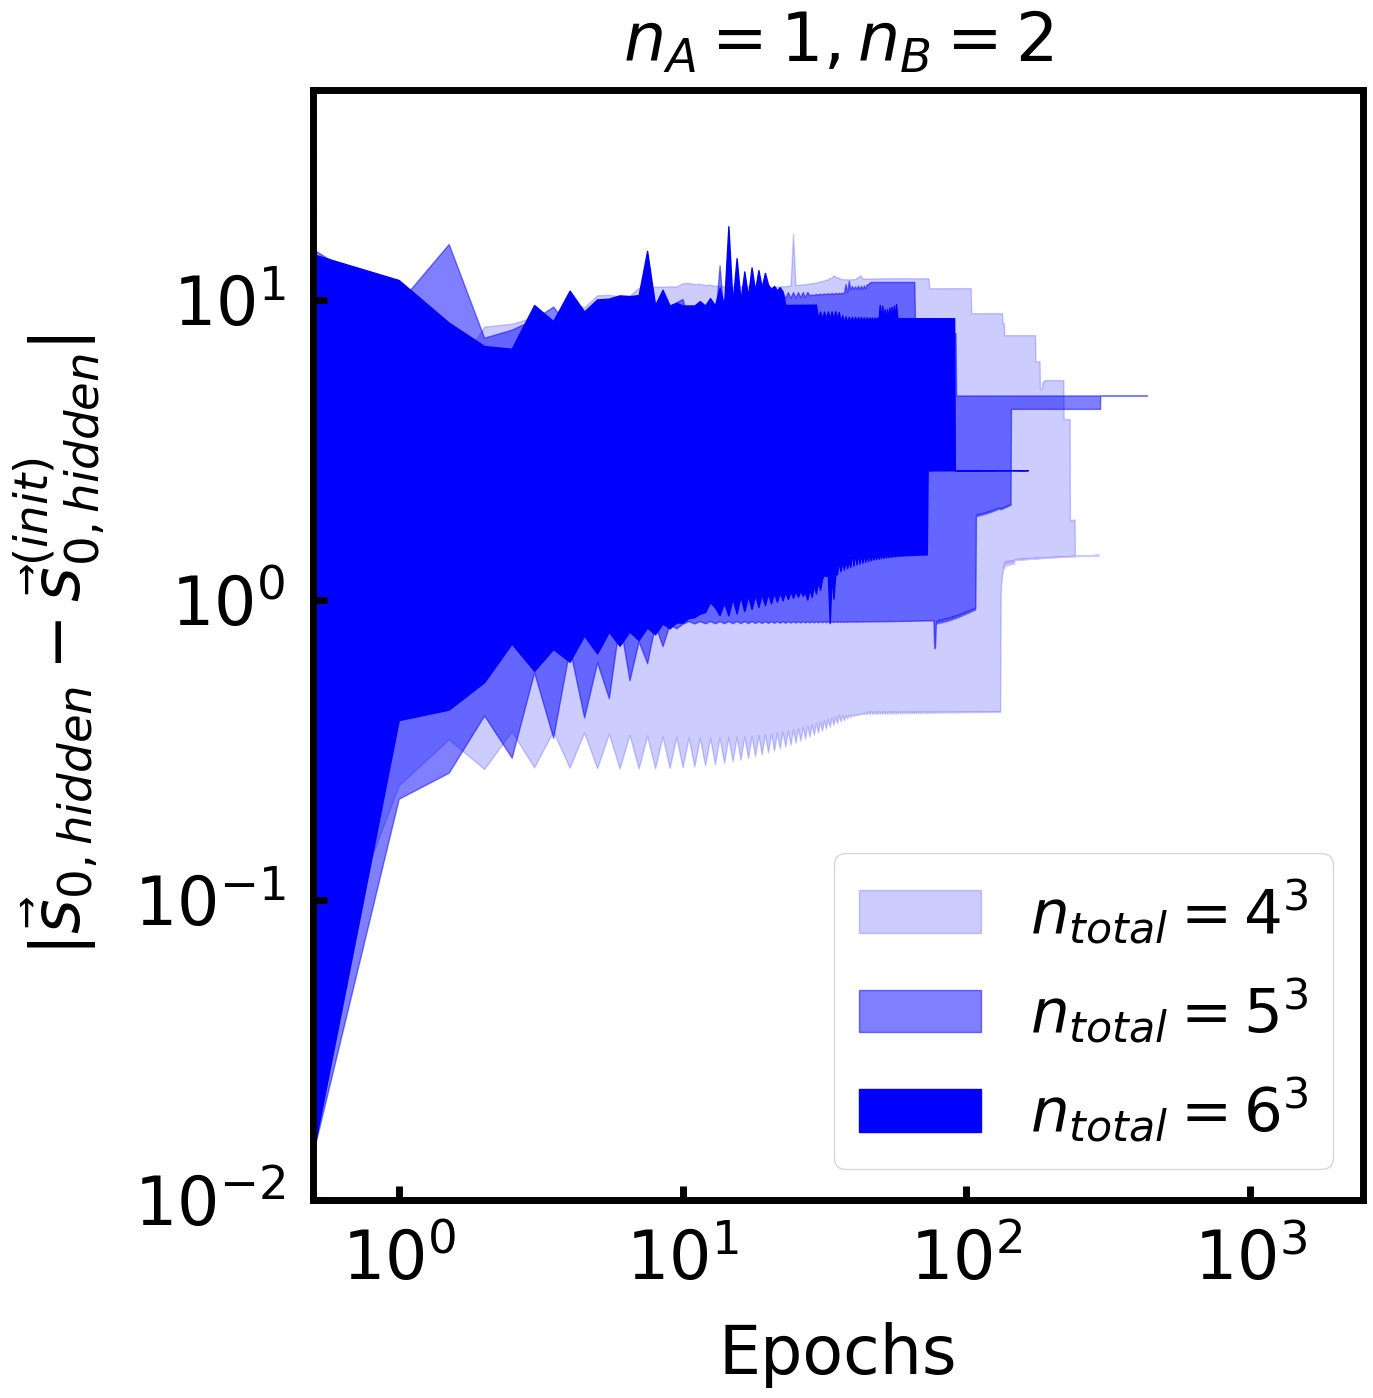

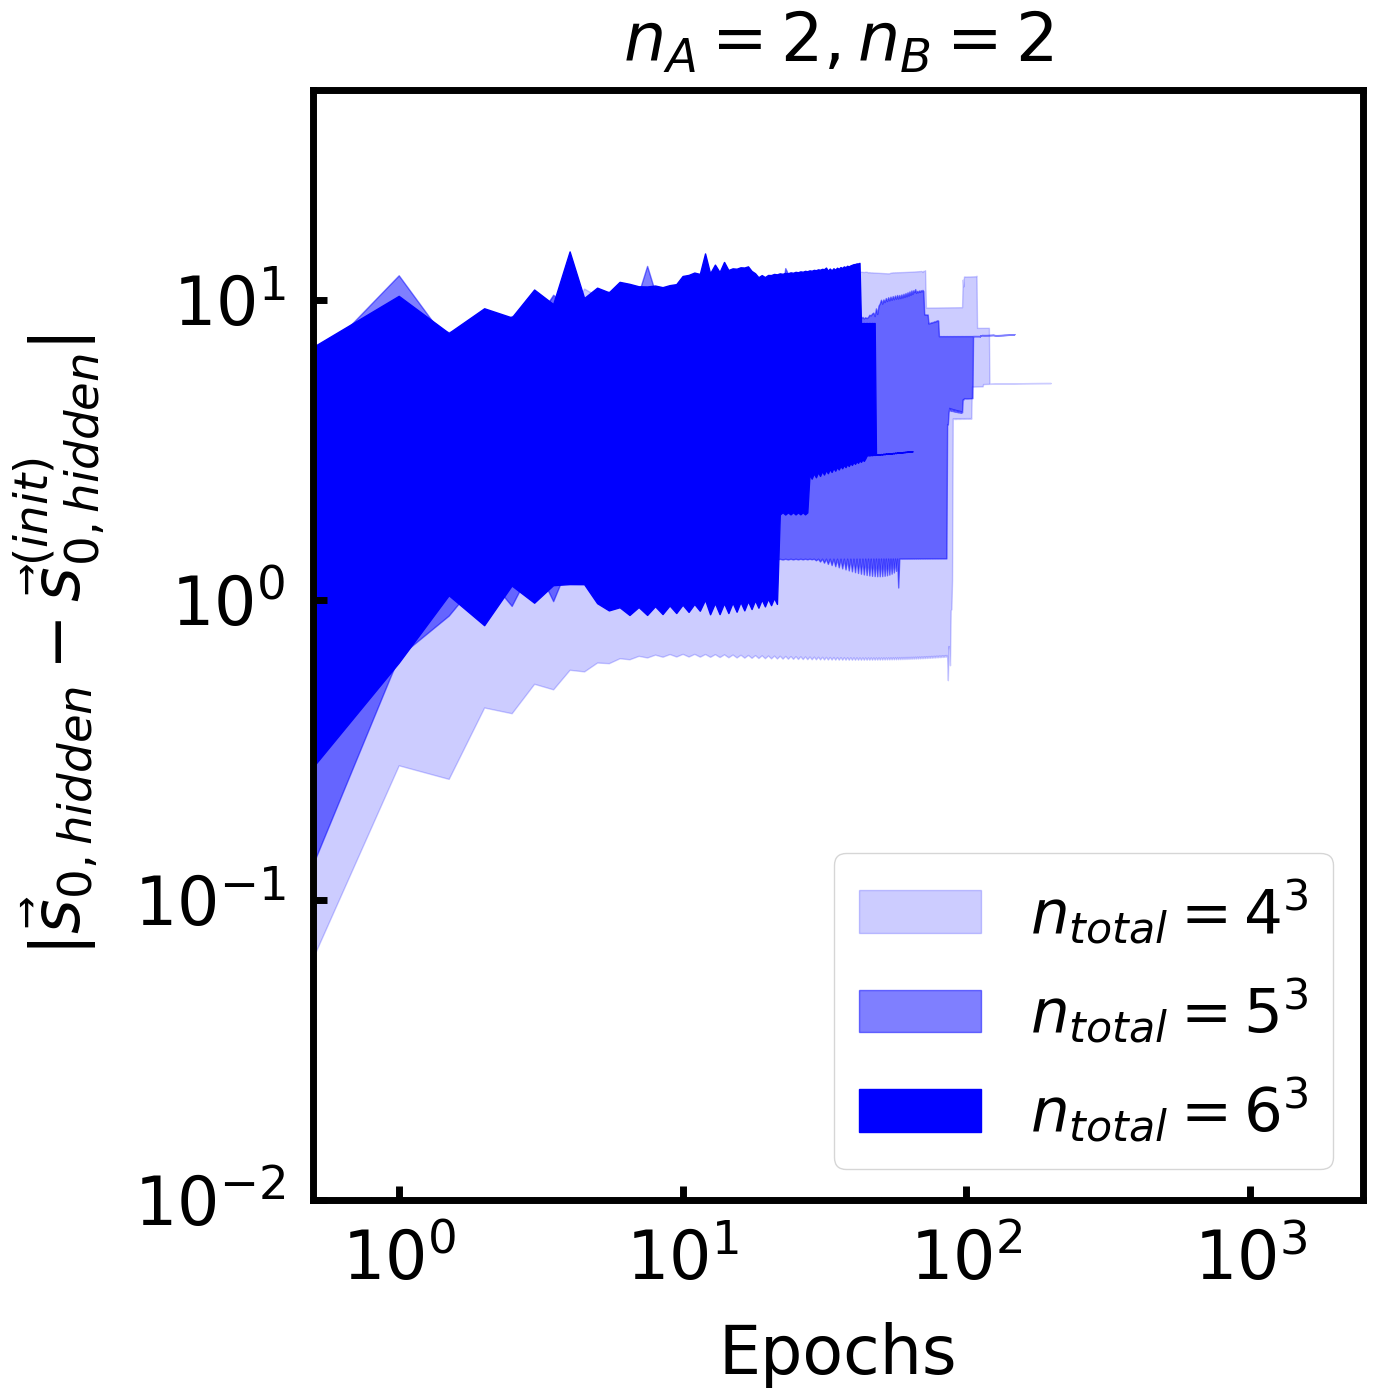

In [1]:
from plotgenerator import distance_to_epoch_multiple_patterns
distance_to_epoch_multiple_patterns()

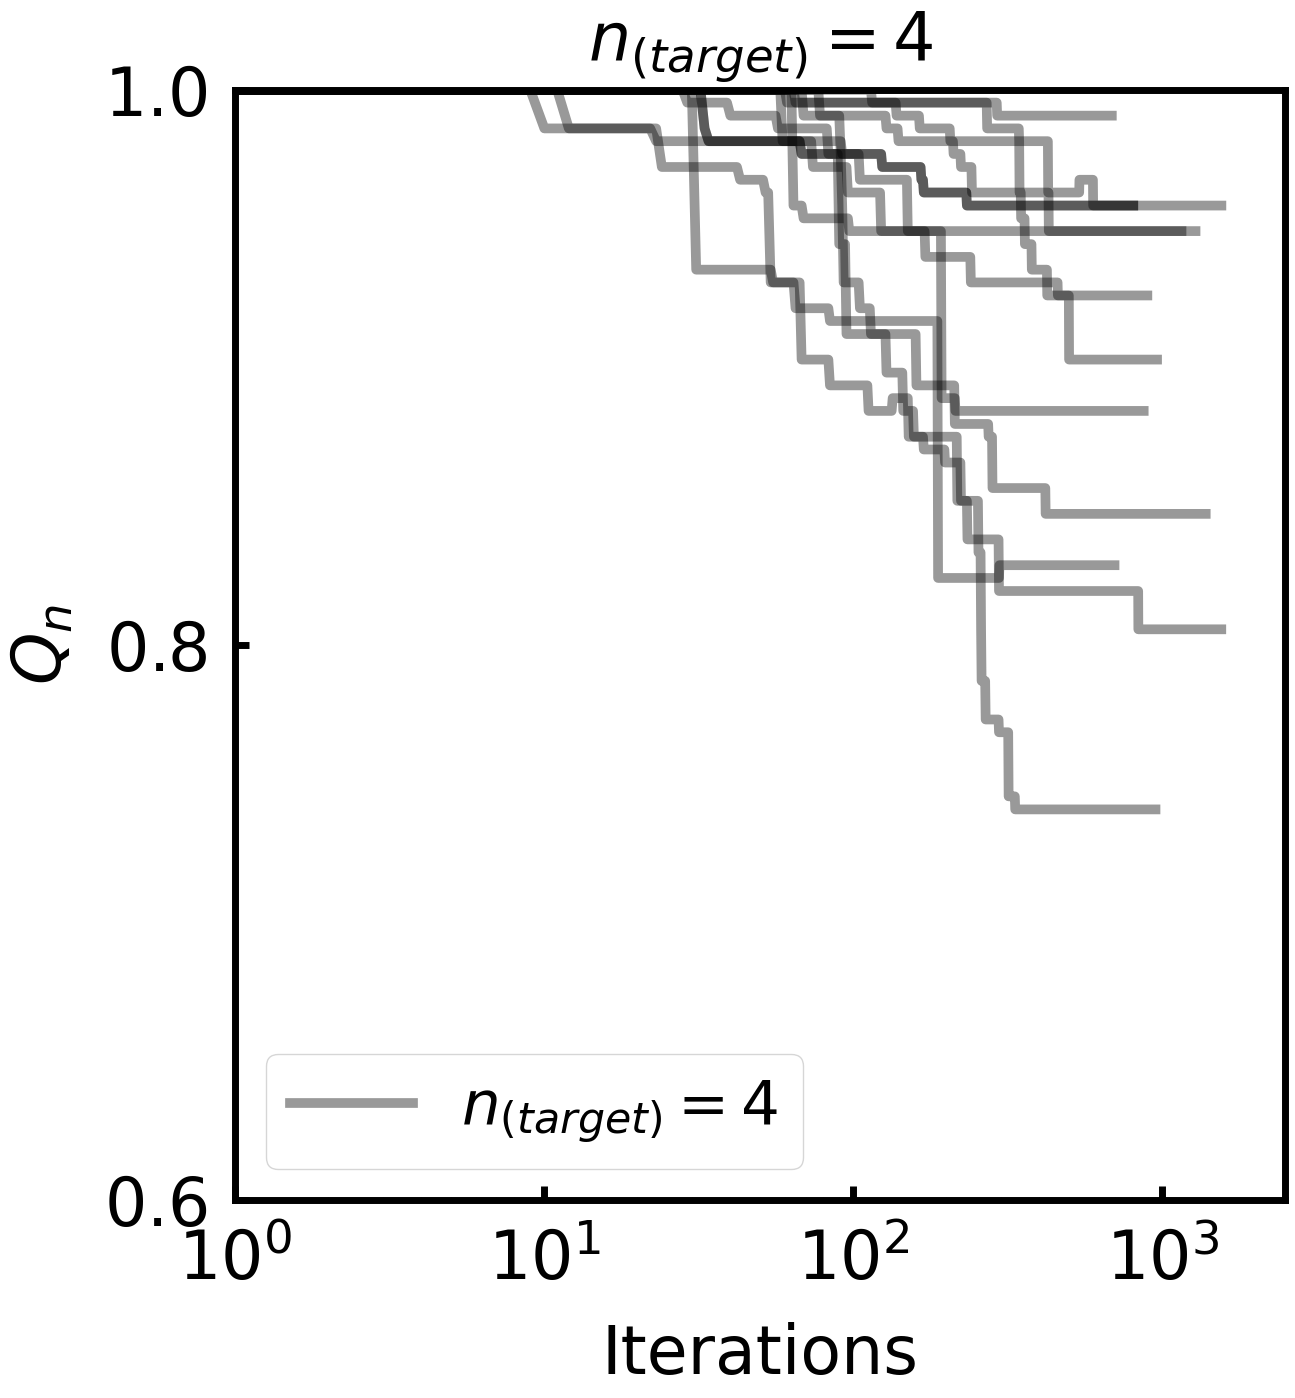

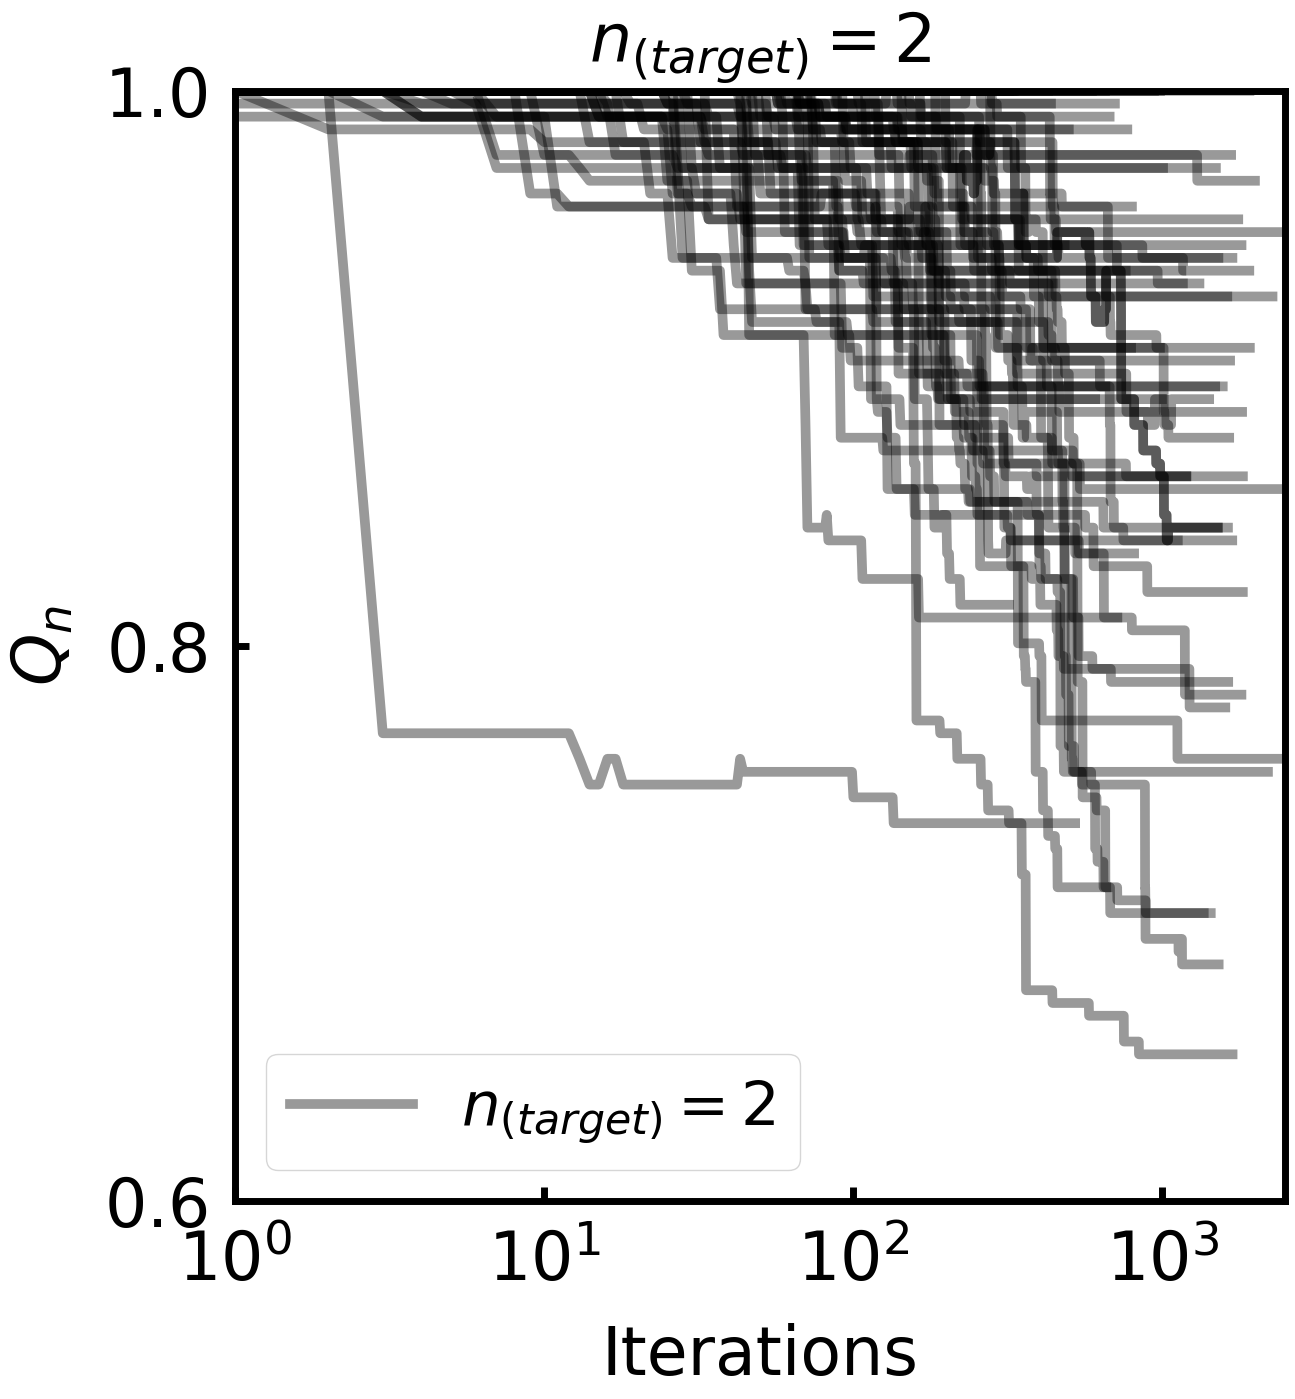

In [17]:
from toolbox import manuscriptPlots
import os
import numpy as np
def overlap_to_iter_single_tracks():
    for n_target in [4,2]:
        plotter = manuscriptPlots.plot()
        # plotter.set_ylim(5e-6,5e0)
        plotter.set_ylim(0.6,1)

        plotter.set_xlim(1,2500)
        plotter.set_xticks([20*i for i in range(150)])
        plotter.set_yticks([5*i for i in range(1,100)])
        plotter.set_yticks([0.2*i for i in range(1,100)])

        plotter.set_xlabel("Iterations")
        # plotter.set_ylabel(r"$(|1-\sigma_{target}/\sigma|)$")
        plotter.set_ylabel(r"$Q_n$")

        # plotter.set_title(r"$n_{(target)} =$"+ "{}".format(n_target))
        plotter.set_yScaled()

        plotter.initialize_figure()
        for size in [6]:
            legend_added = False
            for i in range(100):
                dir = "data/{}_cells_mean_l_{}/{:03d}/".format(n_target,size,i)
                if not os.path.isfile(dir+"errors.txt"):
                    continue
                errors = np.loadtxt(dir+"q_values.txt")
                # if errors[-1]>1e-4:
                #     continue
                # errors = np.loadtxt(dir+"q_values.txt")

                x_array = [i+1 for i in range(len(errors))]
                plotter.plot_xy(x_array, errors, color = "black", alpha = 0.4,label = "_none")
                if legend_added:
                    continue
                plotter.plot_xy(x_array, errors, color = "black", alpha = 0.4, label = r"$n_{(target)}=$"+r'${}$'.format(n_target))
                legend_added = True


        # plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
        plotter.ax.set_xscale("log")
        # plotter.ax.set_yscale("log")
        plotter.ax.legend(loc='lower left')
        # plotter.save_fig("graphs/errors_n_total_4_tarxget_cells.jpg")
overlap_to_iter_single_tracks()

In [ ]:
from toolbox import manuscriptPlots
import os
import numpy as np

graph_output = "graphs/overlaps_n_target_cells_l_6.jpg"
plotter = manuscriptPlots.plot()
plotter.set_ylim(0.5,1.02)
plotter.set_xlim(1,5000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Iterations")
plotter.set_ylabel(r"$Q_n$")

plotter.set_yScaled()
plotter.initialize_figure()
colors = {2:"purple",3:"red",4:"blue",5:"yellow",6:"green"}
alphas = {2:0.2,3:0.3,4:0.4,5:0.5,6:0.6}
for target in [2,4,6]:
    legend_added = False
    overlaps_dict = {}
    max_len = 0
    for i in range(100):
        dir = "data/{}_cells_mean_l_6/{:03d}/".format(target,i)
        if not os.path.isfile(dir+"errors.txt"):
            continue
        # errors = np.loadtxt(dir+"q_values.txt")
        errors = np.loadtxt(dir+"errors.txt")
        if errors[-1]>1e-4:
            continue
        overlaps = np.loadtxt(dir+"q_values.txt")
        overlaps_dict[i] = overlaps
        if len(overlaps)>max_len:
            max_len = len(overlaps)

    iter_to_overlaps = {i: [] for i in range(max_len)}
    for _, errors_array in overlaps_dict.items():
        for iter_idx in range(len(errors_array)):
            iter_to_overlaps[iter_idx].append(errors_array[iter_idx])
    # mean_errors = []
    # for iter_idx in range(max_len):
    #     mean_errors.append(np.mean(iter_to_overlaps[iter_idx]))
    # x_array = [i+1 for i in range(len(mean_errors))]
    # for i, errors in errors_dict.items():
    max_errors = []
    min_errors = []
    for iter_idx in range(max_len):
        if len(iter_to_overlaps[iter_idx])==0:
            break
        max_errors.append(np.max(iter_to_overlaps[iter_idx]))
        min_errors.append(np.min(iter_to_overlaps[iter_idx]))
    x_array = [i+1 for i in range(len(max_errors))]
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4,label = "_none")
    # if legend_added:
    #     continue
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4, label = r"$n_{cells}^{(target)}$"+"={}".format(target))
    legend_added = True
    plotter.plot_max_min_fill(x_array, max_errors, min_errors, color = colors[target], alpha = alphas[target], label = r"$n_{cells}^{(target)}$"+"={}".format(target))


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(title = r"$n_{cells}^{(total)} = 216$",title_fontsize = 48,loc='lower left')
plotter.save_fig(graph_output)


In [ ]:
from toolbox import manuscriptPlots
import os
import numpy as np

graph_output = "graphs/overlaps_n_total_cells.jpg"
plotter = manuscriptPlots.plot()
plotter.set_ylim(0.1,1.02)
plotter.set_xlim(1,3000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Iterations")
plotter.set_ylabel(r"$Q_n$")

plotter.set_yScaled()
plotter.initialize_figure()
colors = {2:"purple",3:"red",4:"blue",5:"yellow",6:"green"}
alphas = {2:0.2,3:0.3,4:0.4,5:0.5,6:0.6}
for size in [4,5,6]:
    legend_added = False
    overlaps_dict = {}
    max_len = 0
    for i in range(100):
        dir = "data/4_cells_mean_l_{}/{:03d}/".format(size,i)
        if not os.path.isfile(dir+"errors.txt"):
            continue
        # errors = np.loadtxt(dir+"q_values.txt")
        errors = np.loadtxt(dir+"errors.txt")
        if errors[-1]>1e-4:
            continue
        overlaps = np.loadtxt(dir+"q_values.txt")
        overlaps_dict[i] = overlaps
        if len(overlaps)>max_len:
            max_len = len(overlaps)

    iter_to_overlaps = {i: [] for i in range(max_len)}
    for _, errors_array in overlaps_dict.items():
        for iter_idx in range(len(errors_array)):
            iter_to_overlaps[iter_idx].append(errors_array[iter_idx])
    # mean_errors = []
    # for iter_idx in range(max_len):
    #     mean_errors.append(np.mean(iter_to_overlaps[iter_idx]))
    # x_array = [i+1 for i in range(len(mean_errors))]
    # for i, errors in errors_dict.items():
    max_errors = []
    min_errors = []
    for iter_idx in range(max_len):
        if len(iter_to_overlaps[iter_idx])==0:
            break
        max_errors.append(np.max(iter_to_overlaps[iter_idx]))
        min_errors.append(np.min(iter_to_overlaps[iter_idx]))
    x_array = [i+1 for i in range(len(max_errors))]
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4,label = "_none")
    # if legend_added:
    #     continue
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4, label = r"$n_{cells}^{(target)}$"+"={}".format(target))
    legend_added = True
    plotter.plot_max_min_fill(x_array, max_errors, min_errors, color = colors[size], alpha = alphas[target], label = r"$n_{cells}^{(total)}$"+"={}".format(size**3))


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(title = r"$n_{cells}^{(target)} = 4$",title_fontsize = 48,loc='lower left')
plotter.save_fig(graph_output)


In [ ]:
from toolbox import manuscriptPlots
import os
import numpy as np

graph_output = "graphs/errors_n_target_cells_l_6.jpg"
plotter = manuscriptPlots.plot()
plotter.set_ylim(5e-7,5)
plotter.set_xlim(1,5000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Iterations")
plotter.set_ylabel(r"$\frac{|\sigma_{target}-\sigma|}{\sigma}$")

plotter.set_yScaled()
plotter.initialize_figure()
colors = {2:"purple",3:"red",4:"blue",5:"yellow",6:"green"}
alphas = {2:0.2,3:0.3,4:0.4,5:0.5,6:0.6}
for target in [2,4,6]:
    legend_added = False
    errors_dict = {}
    max_len = 0
    for i in range(100):
        dir = "data/{}_cells_mean_l_6/{:03d}/".format(target,i)
        if not os.path.isfile(dir+"errors.txt"):
            continue
        # errors = np.loadtxt(dir+"q_values.txt")
        errors = np.loadtxt(dir+"errors.txt")
        if errors[-1]>1e-4:
            continue

        errors_dict[i] = errors
        if len(errors)>max_len:
            max_len = len(errors)

    iter_to_errors = {i: [] for i in range(max_len)}
    for _, errors_array in errors_dict.items():
        for iter_idx in range(len(errors_array)):
            iter_to_errors[iter_idx].append(errors_array[iter_idx])
    mean_errors = []
    for iter_idx in range(max_len):
        mean_errors.append(np.mean(iter_to_errors[iter_idx]))
    x_array = [i+1 for i in range(len(mean_errors))]
    errors = mean_errors
    # for i, errors in errors_dict.items():
    max_errors = []
    min_errors = []
    for iter_idx in range(max_len):
        max_errors.append(np.max(iter_to_errors[iter_idx]))
        min_errors.append(np.min(iter_to_errors[iter_idx]))
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4,label = "_none")
    # if legend_added:
    #     continue
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4, label = r"$n_{cells}^{(target)}$"+"={}".format(target))
    legend_added = True
    plotter.plot_max_min_fill(x_array, max_errors, min_errors, color = colors[target], alpha = alphas[target], label = r"$n_{cells}^{(target)}$"+"={}".format(target))


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
plotter.ax.legend(title = r"$n_{cells}^{(total)} = 6^3$",title_fontsize = 48,loc='lower left')
plotter.save_fig(graph_output)


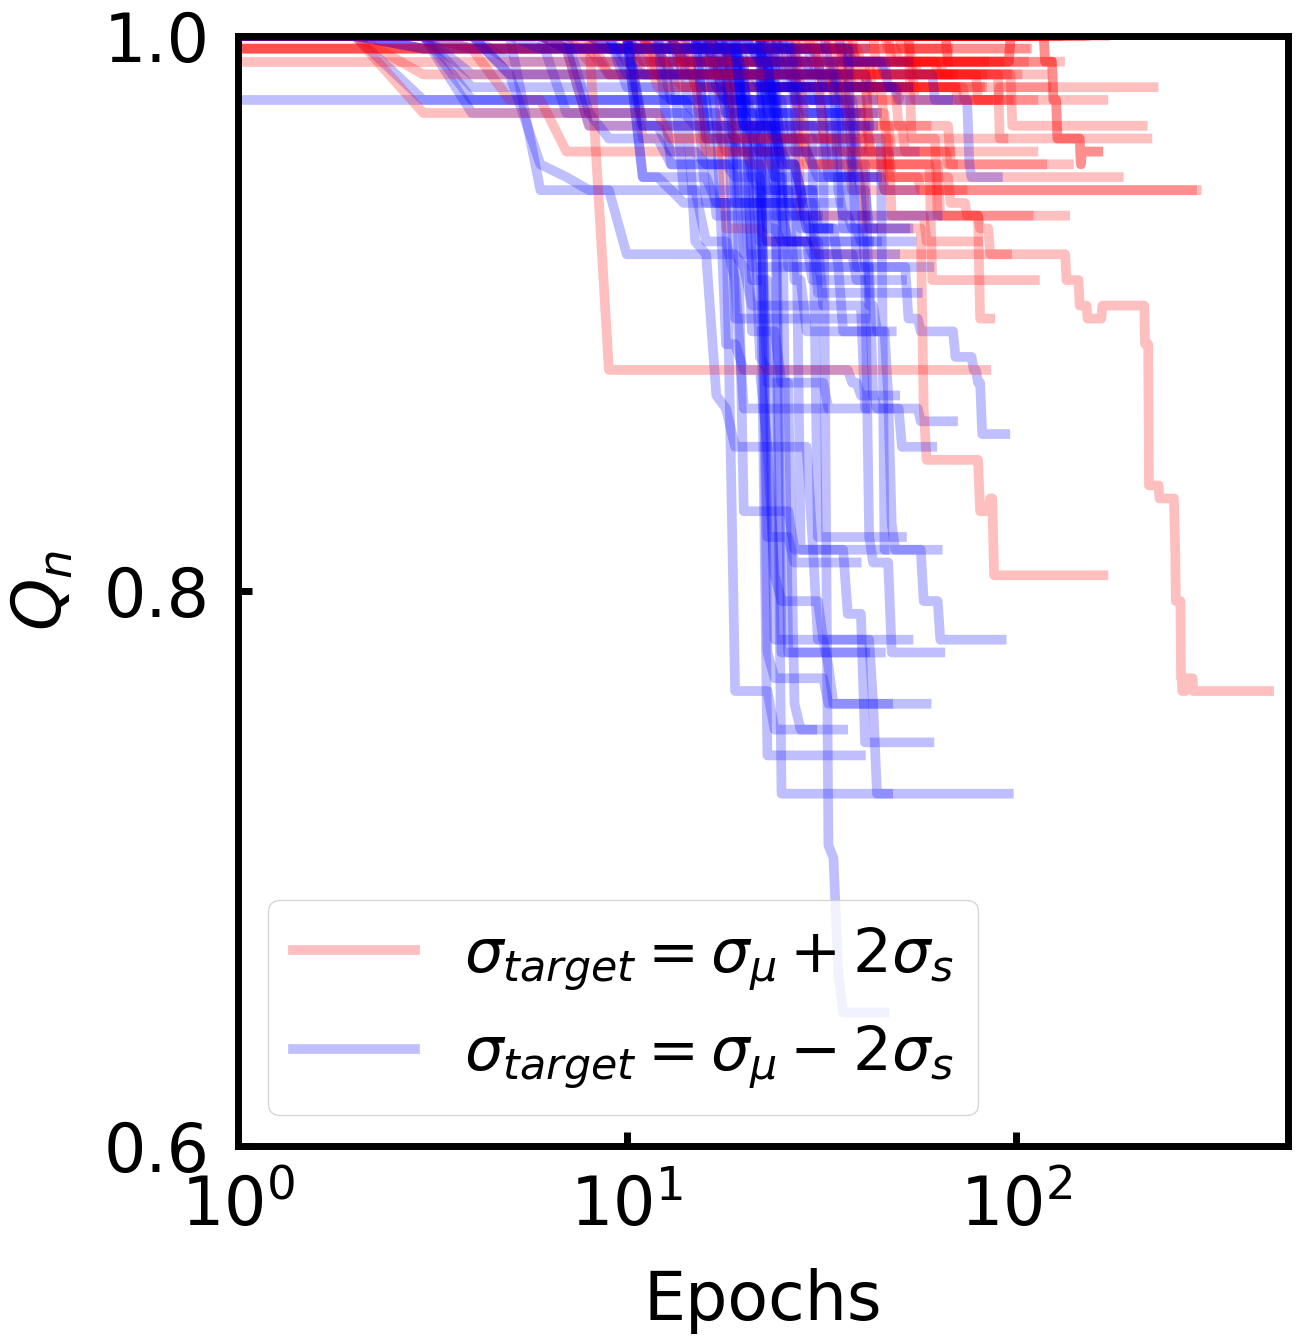

In [ ]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(0.6,1)
plotter.set_xlim(1,500)
plotter.set_xticks([500*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$Q_n$")
# plotter.set_yScaled()
plotter.initialize_figure()
for i in range(100):
    dir = "data/1_cell_increase_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt("{}errors.txt".format(dir))
    if errors[-1]>5e-6:
        continue
    q_values = np.loadtxt(dir+"q_values.txt")
    # print(dir, errors[-1])
    x_array = [i+1 for i in range(len(q_values))]
    plotter.plot_xy(x_array, q_values, color ="red", alpha = 0.25,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, q_values, color ="red", alpha = 0.25, label = r"$\sigma_{target}=\sigma_\mu + 2\sigma_s$")
    dir = "data/1_cell_decrease_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt("{}errors.txt".format(dir))
    if errors[-1]>5e-6:
        continue
    q_values = np.loadtxt(dir+"q_values.txt")
    # print(dir, errors[-1])
    x_array = [i+1 for i in range(len(q_values))]
    plotter.plot_xy(x_array, q_values, color ="blue", alpha = 0.25,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, q_values, color ="blue", alpha = 0.25, label = r"$\sigma_{target}=\sigma_\mu - 2\sigma_s$")


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='lower left')
plotter.save_fig("new_graphs/single_cell_overlaps.jpg")


In [ ]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(0,1.08)
plotter.set_xlim(1,3000)
plotter.set_xticks([1000*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$Q_n$")

plotter.initialize_figure()
# legend_added = False
# for i in range(100):
#     dir = "data/4_cells_mean/{:03d}/".format(i)
#     if not os.path.isfile(dir+"errors.txt"):
#         continue
#     q_values = np.loadtxt(dir+"q_values.txt")
#     # print(dir, errors[-1])
#     x_array = [i+1 for i in range(len(q_values))]
#     plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1,label = "_none")
    
#     if legend_added:
#         continue
#     plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu$")
#     legend_added = True

colors = {4:"red",5:"blue",6:"yellow"}
for size in [4,5,6]:
    legend_added = False
    for i in range(100):
        dir = "data/4_cells_mean_l_{}/{:03d}/".format(size,i)
        if not os.path.isfile(dir+"q_values.txt"):
            continue
        with open(dir+"q_values.txt","r") as f:
            lines = f.readlines()
            if len(lines)<2:
                continue
        errors = np.loadtxt(dir+"q_values.txt")
        x_array = [i+1 for i in range(len(errors))]
        plotter.plot_xy(x_array, errors, color = colors[size], alpha = 0.4,label = "_none")
        if legend_added:
            continue
        plotter.plot_xy(x_array, errors, color = colors[size], alpha = 0.4, label = "L = {}".format(size))
        legend_added = True
# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/4_cells_overlap_all_sizes.jpg")


In [ ]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(0,1.08)
plotter.set_xlim(1,3000)
plotter.set_xticks([1000*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$Q_n$")

plotter.set_yScaled()
plotter.initialize_figure()
# legend_added = False
# for i in range(100):
#     dir = "data/4_cells_mean/{:03d}/".format(i)
#     if not os.path.isfile(dir+"errors.txt"):
#         continue
#     q_values = np.loadtxt(dir+"q_values.txt")
#     # print(dir, errors[-1])
#     x_array = [i+1 for i in range(len(q_values))]
#     plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1,label = "_none")
    
#     if legend_added:
#         continue
#     plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu$")
#     legend_added = True

colors = {2:"red",3:"blue",4:"yellow",5:"yellow",6:"green"}
for n_cells in []:
    legend_added = False
    for i in range(100):
        dir = "data/{}_cells_mean_l_6/{:03d}/".format(n_cells,i)
        if not os.path.isfile(dir+"q_values.txt"):
            continue
        with open(dir+"q_values.txt","r") as f:
            lines = f.readlines()
            if len(lines)<2:
                continue
        errors = np.loadtxt(dir+"q_values.txt")
        x_array = [i+1 for i in range(len(errors))]
        plotter.plot_xy(x_array, errors, color = colors[n_cells], alpha = 0.4,label = "_none")
        if legend_added:
            continue
        plotter.plot_xy(x_array, errors, color = colors[n_cells], alpha = 0.4, label = "n = {}".format(n_cells))
        legend_added = True
# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/overlaps_all_sizes.jpg")
